# Conditional Multi-Target NCA — 64x64
Trains **one** NCA update rule that can grow into *any of several* target images (e.g. different room/layout designs), selected by a learned conditioning embedding.

Unlike a single-target NCA, the conditioning vector is injected fresh into every step as an external signal (not stored as mutable state), so it survives damage/erasure — the network always knows 'which layout it's growing' even if the visible pattern is destroyed.

Runs on Colab T4.

In [2]:
#@title 1. Setup
import torch, numpy as np, os, glob
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


Device: cuda
Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#@title 2. Upload target images (select multiple at once)
from google.colab import files
uploaded = files.upload()  # select ALL your room/layout images in the file picker at once
IMAGE_PATHS = sorted(uploaded.keys())
NUM_LAYOUTS = len(IMAGE_PATHS)
print(f"Uploaded {NUM_LAYOUTS} images:")
for p in IMAGE_PATHS:
    print(" -", p)


Saving 1.png to 1.png
Saving 2.png to 2.png
Saving 3.png to 3.png
Saving 4.png to 4.png
Uploaded 4 images:
 - 1.png
 - 2.png
 - 3.png
 - 4.png


In [5]:
#@title 3. Config
SIZE = 64
CHANNELS = 16          # RGBA(4) + hidden(12), same as single-target version
COND_DIM = 8            # size of the learned per-layout embedding
HIDDEN = 192             # bumped up from 128 -- conditioning adds a harder task
BATCH_SIZE = 8
POOL_SIZE = 1024
TRAIN_STEPS = 20000      # multi-target needs more steps than single-target (was 8000)
MIN_NCA_STEPS = 64
MAX_NCA_STEPS = 96
LR = 2e-3
FIRE_RATE = 0.5
DAMAGE_FRACTION = 1/3    # fraction of each batch to randomly damage (regeneration training)
AMP = True
LOG_EVERY = 100
PREVIEW_EVERY = 500
OUT_DIR = "/content/drive/MyDrive/nca_out" # Changed to save to Google Drive
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Training a single NCA conditioned across {NUM_LAYOUTS} layouts.")
if NUM_LAYOUTS > 32:
    print("NOTE: >32 layouts is pushing this small architecture -- consider HIDDEN=256+ and more steps.")

Training a single NCA conditioned across 4 layouts.


targets shape: torch.Size([4, 4, 64, 64])


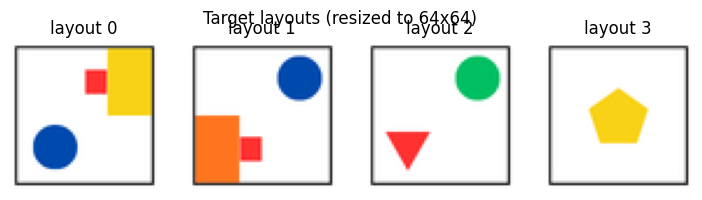

In [6]:
#@title 4. Load all target images into one tensor
def load_target(path, size):
    img = Image.open(path).convert("RGBA")
    img = img.resize((size, size), Image.LANCZOS)
    arr = np.array(img).astype(np.float32) / 255.0
    rgb, a = arr[..., :3], arr[..., 3:4]
    arr = np.concatenate([rgb * a, a], axis=-1)  # premultiply alpha
    return torch.from_numpy(arr).permute(2, 0, 1)  # 4, H, W

targets = torch.stack([load_target(p, SIZE) for p in IMAGE_PATHS]).to(device)  # (N, 4, H, W)
print("targets shape:", targets.shape)

def rgba_to_rgb(x):
    rgb, a = x[:, :3], x[:, 3:4].clamp(0, 1)
    return rgb + (1.0 - a)

# Sanity check: show all uploaded targets
fig, axes = plt.subplots(1, NUM_LAYOUTS, figsize=(2.2 * NUM_LAYOUTS, 2.2))
if NUM_LAYOUTS == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(rgba_to_rgb(targets[i:i+1])[0].permute(1, 2, 0).cpu().numpy())
    ax.set_title(f"layout {i}")
    ax.axis("off")
plt.suptitle("Target layouts (resized to %dx%d)" % (SIZE, SIZE))
plt.show()


In [7]:
#@title 5. Conditional NCA model
class ConditionalNCA(nn.Module):
    def __init__(self, channels=16, hidden=128, cond_dim=8, fire_rate=0.5):
        super().__init__()
        self.channels = channels
        self.cond_dim = cond_dim
        self.fire_rate = fire_rate

        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32) / 8.0
        sobel_y = sobel_x.t()
        identity = torch.zeros(3, 3)
        identity[1, 1] = 1.0
        kernels = torch.stack([identity, sobel_x, sobel_y])
        kernels = kernels.repeat(channels, 1, 1).unsqueeze(1)
        self.register_buffer("perception_kernels", kernels)

        # Update MLP now takes perception (channels*3) + conditioning (cond_dim)
        self.update = nn.Sequential(
            nn.Conv2d(channels * 3 + cond_dim, hidden, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
        )
        nn.init.zeros_(self.update[-1].weight)

    def perceive(self, x):
        return F.conv2d(
            F.pad(x, (1, 1, 1, 1), mode="circular"),
            self.perception_kernels,
            groups=self.channels,
        )

    def alive_mask(self, x):
        alpha = x[:, 3:4, :, :]
        alive = F.max_pool2d(
            F.pad(alpha, (1, 1, 1, 1), mode="circular"), kernel_size=3, stride=1
        ) > 0.1
        return alive

    def forward(self, x, cond):
        # x: (B, C, H, W)   cond: (B, cond_dim)
        B, _, H, W = x.shape
        cond_map = cond.view(B, self.cond_dim, 1, 1).expand(-1, -1, H, W)

        pre_life = self.alive_mask(x)
        y = self.perceive(x)
        y = torch.cat([y, cond_map], dim=1)  # inject conditioning fresh every step
        dx = self.update(y)

        update_mask = (torch.rand(B, 1, H, W, device=x.device) <= self.fire_rate).float()
        x = x + dx * update_mask

        post_life = self.alive_mask(x)
        life_mask = (pre_life & post_life).float()
        return x * life_mask


def make_seed(size, channels, device):
    seed = torch.zeros(channels, size, size, device=device)
    seed[3:, size // 2, size // 2] = 1.0
    return seed


class ConditionalSamplePool:
    """Each pool slot tracks both its cell-state AND which layout it belongs to."""
    def __init__(self, seed, pool_size, num_layouts):
        self.pool_size = pool_size
        self.slots = seed.detach().cpu().unsqueeze(0).repeat(pool_size, 1, 1, 1).clone()
        # Assign layouts round-robin so every layout is represented evenly at init
        self.layout_ids = torch.arange(pool_size) % num_layouts

    def sample(self, batch_size, device):
        idx = np.random.choice(self.pool_size, batch_size, replace=False)
        x = self.slots[idx].clone().to(device)
        layout_ids = self.layout_ids[idx].clone().to(device)
        return idx, x, layout_ids

    def update(self, idx, batch):
        self.slots[idx] = batch.detach().cpu()

    def reseed(self, idx_in_batch, pool_idx, seed):
        """Reset one batch item back to blank seed, keep its layout_id unchanged."""
        pass  # handled inline in training loop (state reset only, layout stays fixed)


In [8]:
#@title 6. Build model, optimizer, embedding, seed pool
model = ConditionalNCA(channels=CHANNELS, hidden=HIDDEN, cond_dim=COND_DIM, fire_rate=FIRE_RATE).to(device)
embedding = nn.Embedding(NUM_LAYOUTS, COND_DIM).to(device)

opt = torch.optim.Adam(list(model.parameters()) + list(embedding.parameters()), lr=LR)
sched = torch.optim.lr_scheduler.MultiStepLR(
    opt, milestones=[int(TRAIN_STEPS * 0.7), int(TRAIN_STEPS * 0.9)], gamma=0.3
)

seed = make_seed(SIZE, CHANNELS, device)
pool = ConditionalSamplePool(seed, POOL_SIZE, NUM_LAYOUTS)
scaler = torch.cuda.amp.GradScaler(enabled=AMP)

n_params = sum(p.numel() for p in model.parameters()) + sum(p.numel() for p in embedding.parameters())
print(f"Total trainable parameters (NCA + embedding): {n_params:,}")


Total trainable parameters (NCA + embedding): 14,048


/tmp/ipykernel_1494/924143027.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP)


In [9]:
import glob

# Check for existing checkpoints and load the latest one
checkpoint_files = sorted(glob.glob(os.path.join(OUT_DIR, "conditional_nca_model.pt")))
if checkpoint_files:
    latest_checkpoint = checkpoint_files[-1]
    print(f"Loading checkpoint from {latest_checkpoint}")
    checkpoint = torch.load(latest_checkpoint, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    embedding.load_state_dict(checkpoint["embedding_state"])

    # Check if optimizer, scheduler, and step are in the checkpoint (for newer checkpoints)
    if "optimizer_state" in checkpoint and "scheduler_state" in checkpoint and "step" in checkpoint:
        opt.load_state_dict(checkpoint["optimizer_state"])
        sched.load_state_dict(checkpoint["scheduler_state"])
        start_step = checkpoint["step"] + 1
        losses_log = checkpoint.get("losses_log", []) # Load previous losses if available
        print("Model, embedding, optimizer, scheduler, and training step loaded successfully.")
    else:
        # Old checkpoint format: load model/embedding but restart optimizer/scheduler/step
        print("Warning: Old checkpoint format detected. Loading model and embedding, but restarting optimizer, scheduler, and training from step 1.")
        start_step = 1
        losses_log = [] # Start losses_log fresh if restarting from an old checkpoint
else:
    print("No checkpoint found. Starting training from scratch.")
    start_step = 1
    losses_log = [] # Initialize losses_log for new training

Loading checkpoint from /content/drive/MyDrive/nca_out/conditional_nca_model.pt
Model, embedding, optimizer, scheduler, and training step loaded successfully.


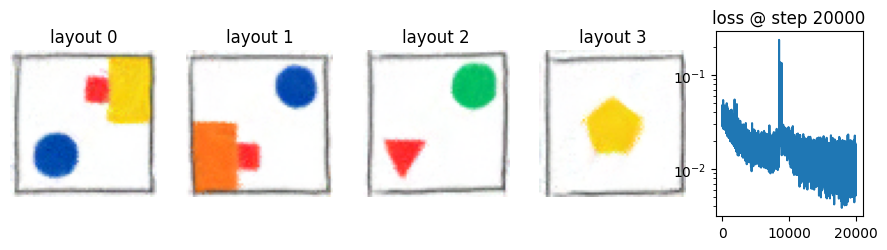

Training complete.


In [10]:

def grow_layout(layout_id, n_steps=96):
    model.eval()
    with torch.no_grad():
        x = seed.unsqueeze(0).clone()
        cond = embedding(torch.tensor([layout_id], device=device))
        for _ in range(n_steps):
            x = model(x, cond)
        img = rgba_to_rgb(x)[0].clamp(0, 1).cpu().permute(1, 2, 0).numpy()
    model.train()
    return img

yy, xx = torch.meshgrid(
    torch.arange(SIZE, device=device), torch.arange(SIZE, device=device), indexing="ij"
)

for i in range(start_step, TRAIN_STEPS + 1):
    idx, x, layout_ids = pool.sample(BATCH_SIZE, device)

    # --- Damage injection: teach regeneration, not just growth ---
    n_damage = max(1, x.shape[0] // 3)
    damage_idx = np.random.choice(x.shape[0], n_damage, replace=False)
    for b in damage_idx:
        cy = np.random.randint(0, SIZE)
        cx = np.random.randint(0, SIZE)
        r = np.random.randint(SIZE // 8, SIZE // 3)
        mask = ((yy - cy) ** 2 + (xx - cx) ** 2) < (r ** 2)
        x[b, :, mask] = 0.0

    # --- Persistence: reseed the worst-performing sample back to blank ---
    with torch.no_grad():
        cond_all = embedding(layout_ids)
        per_item_target = targets[layout_ids]  # gather correct target per batch item
        cur_losses = ((x[:, :4] - per_item_target) ** 2).mean(dim=[1, 2, 3])
        worst = cur_losses.argmax().item()
        x[worst] = seed.clone()  # layout_id for this slot stays the same, only state resets

    # n_steps = np.random.randint(MIN_NCA_STEPS, MAX_NCA_STEPS + 1)

    # opt.zero_grad()
    # with torch.cuda.amp.autocast(enabled=AMP):
    #     cond = embedding(layout_ids)  # (B, COND_DIM), recompute inside autocast/graph
    #     for _ in range(n_steps):
    #         x = model(x, cond)
    #     per_item_target = targets[layout_ids]
    #     loss = ((x[:, :4] - per_item_target) ** 2).mean()


    n_steps = np.random.randint(MIN_NCA_STEPS, MAX_NCA_STEPS + 1)

    # --- Transition training: teach reshaping between layouts, not just growth ---
    transition_frac = 0.3  # fraction of batch that does a mid-rollout layout switch
    is_transition = torch.rand(x.shape[0], device=device) < transition_frac

    to_layout_ids = layout_ids.clone()
    switch_step = torch.full((x.shape[0],), n_steps + 1, device=device)  # non-transition items never switch
    if is_transition.any():
        # pick a different target layout for the "after" phase
        rand_offset = torch.randint(1, NUM_LAYOUTS, (x.shape[0],), device=device)
        to_layout_ids = torch.where(is_transition, (layout_ids + rand_offset) % NUM_LAYOUTS, layout_ids)
        switch_step = torch.where(
            is_transition,
            torch.randint(n_steps // 4, (3 * n_steps) // 4, (x.shape[0],), device=device),
            switch_step,
        )

    cond_before = embedding(layout_ids)
    cond_after = embedding(to_layout_ids)

    opt.zero_grad()
    with torch.cuda.amp.autocast(enabled=AMP):
        for t in range(n_steps):
            use_after = (torch.tensor(t, device=device) >= switch_step).float().unsqueeze(1)
            cond_t = cond_before * (1 - use_after) + cond_after * use_after
            x = model(x, cond_t)
        per_item_target = targets[to_layout_ids]   # loss is against wherever it should have ended up
        loss = ((x[:, :4] - per_item_target) ** 2).mean()

    scaler.scale(loss).backward()
    for p in list(model.parameters()) + list(embedding.parameters()):
        if p.grad is not None:
            p.grad = p.grad / (p.grad.norm() + 1e-8)
    scaler.step(opt)
    scaler.update()
    sched.step()

    pool.update(idx, x)
    losses_log.append(loss.item())

    if i % LOG_EVERY == 0 or i == 1:
        print(f"step {i:5d}/{TRAIN_STEPS}  loss={loss.item():.6f}  lr={sched.get_last_lr()[0]:.2e}  nca_steps={n_steps}")

    if i % PREVIEW_EVERY == 0 or i == TRAIN_STEPS:
        clear_output(wait=True)
        n_show = min(NUM_LAYOUTS, 8)
        fig, axes = plt.subplots(1, n_show + 1, figsize=(2.2 * (n_show + 1), 2.4))
        for L in range(n_show):
            axes[L].imshow(grow_layout(L))
            axes[L].set_title(f"layout {L}")
            axes[L].axis("off")
        axes[-1].plot(losses_log)
        axes[-1].set_yscale("log")
        axes[-1].set_title(f"loss @ step {i}")
        plt.show()

        torch.save({
            "model_state": model.state_dict(),
            "embedding_state": embedding.state_dict(),
            "optimizer_state": opt.state_dict(),
            "scheduler_state": sched.state_dict(),
            "step": i,
            "losses_log": losses_log,
            "channels": CHANNELS, "hidden": HIDDEN, "cond_dim": COND_DIM,
            "size": SIZE, "fire_rate": FIRE_RATE, "num_layouts": NUM_LAYOUTS,
            "image_names": IMAGE_PATHS,
        }, os.path.join(OUT_DIR, "conditional_nca_model.pt"))

print("Training complete.")

In [11]:
#@title 8. Download trained model (includes NCA weights + layout embeddings)
from google.colab import files
files.download(os.path.join(OUT_DIR, "conditional_nca_model.pt"))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
def grow_layout(layout_id, n_steps=96):
    model.eval()
    with torch.no_grad():
        x = seed.unsqueeze(0).clone()
        cond = embedding(torch.tensor([layout_id], device=device))
        for _ in range(n_steps):
            x = model(x, cond)
        img = rgba_to_rgb(x)[0].clamp(0, 1).cpu().permute(1, 2, 0).numpy()
    model.train()
    return img


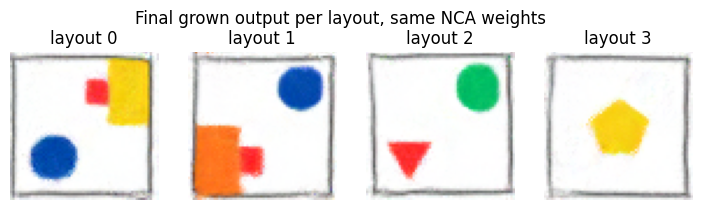

In [13]:
#@title 9. (Optional) Compare all layouts side by side after training
n_show = NUM_LAYOUTS
fig, axes = plt.subplots(1, n_show, figsize=(2.2 * n_show, 2.4))
if n_show == 1:
    axes = [axes]
for L in range(n_show):
    axes[L].imshow(grow_layout(L))
    axes[L].set_title(f"layout {L}")
    axes[L].axis("off")
plt.suptitle("Final grown output per layout, same NCA weights")
plt.show()


## Testing: choosing a layout & switching between them

Two ways to control which layout grows:
1. **Static selection** — pick a `layout_id`, run a fresh growth, look at the result (cell 11).
2. **Live shuffle** — start a continuous growth loop and switch the conditioning vector *while it's running*, watching the pattern morph from one layout toward another in real time (cell 12). This is a good way to sanity-check that the embedding is actually doing something meaningful, since a well-trained conditional NCA should smoothly re-grow toward the new target rather than just freezing or collapsing.

In [14]:
#@title 11. Static layout selection (dropdown, rerun to grow)
import ipywidgets as widgets
from IPython.display import display

layout_options = [(f"{i}: {os.path.basename(IMAGE_PATHS[i])}", i) for i in range(NUM_LAYOUTS)]
layout_dropdown = widgets.Dropdown(options=layout_options, description="Layout:")
steps_slider = widgets.IntSlider(value=96, min=16, max=200, step=8, description="Steps:")
run_button = widgets.Button(description="Grow this layout", button_style="success")
output_area = widgets.Output()

def on_run_clicked(b):
    with output_area:
        clear_output(wait=True)
        img = grow_layout(layout_dropdown.value, n_steps=steps_slider.value)
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Layout {layout_dropdown.value}: {os.path.basename(IMAGE_PATHS[layout_dropdown.value])}")
        plt.axis("off")
        plt.show()

run_button.on_click(on_run_clicked)
display(widgets.VBox([layout_dropdown, steps_slider, run_button, output_area]))


In [ ]:
#@title 12. Live shuffle -- switch layout mid-growth, watch it morph
!pip install ipycanvas -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 107.8 MB/s eta 0:00:00


In [ ]:
#@title 12b. Live shuffle viewer
import threading, time
from ipycanvas import Canvas, hold_canvas

SCALE = 8
canvas = Canvas(width=SIZE * SCALE, height=SIZE * SCALE)
canvas.layout.border = "1px solid black"

shuffle_dropdown = widgets.Dropdown(options=layout_options, description="Layout:")
reset_btn = widgets.Button(description="Reset seed", button_style="warning")
stop_btn = widgets.Button(description="Stop", button_style="danger")
status_label = widgets.Label(value="Pick a layout from the dropdown -- it updates live while growing.")

display(widgets.VBox([status_label, canvas, widgets.HBox([shuffle_dropdown, reset_btn, stop_btn])]))

model.eval()
state_lock = threading.Lock()
with torch.no_grad():
    x_live = seed.unsqueeze(0).clone()
running_flag = {"go": True}

def render(x):
    img = rgba_to_rgb(x)[0].clamp(0, 1).detach().cpu().permute(1, 2, 0).numpy()
    img = (img * 255).astype(np.uint8)
    img_up = np.kron(img, np.ones((SCALE, SCALE, 1), dtype=np.uint8))
    with hold_canvas(canvas):
        canvas.put_image_data(img_up, 0, 0)

def live_loop():
    global x_live
    while running_flag["go"]:
        # Read the dropdown value EVERY step -- this is what makes switching live.
        # Changing cond mid-rollout does not touch the state x_live at all;
        # only which target the network is being steered toward changes.
        layout_id = shuffle_dropdown.value
        cond = embedding(torch.tensor([layout_id], device=device))
        with state_lock:
            with torch.no_grad():
                x_live = model(x_live, cond)
            render(x_live)
        time.sleep(0.05)

def on_reset(b):
    global x_live
    with state_lock:
        x_live = seed.unsqueeze(0).clone()
    status_label.value = "Reset to seed -- will grow toward whichever layout is selected."

def on_stop(b):
    running_flag["go"] = False
    status_label.value = "Stopped."

reset_btn.on_click(on_reset)
stop_btn.on_click(on_stop)

thread = threading.Thread(target=live_loop, daemon=True)
thread.start()


Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()

## Extracting growth trajectories (with layout metadata)

This extends your pseudocode: for a conditional model, each saved trajectory needs to record **which layout produced it** and **what conditioning vector was used** -- otherwise the array of frames is meaningless once you have more than one layout, since a `[steps, 4, H, W]` array alone doesn't tell you which target it was growing toward.

`extract_growth_trajectory()` below saves one `.npz` (a small zip of named numpy arrays) per layout containing:
- `states`: the RGBA frames, shape `[steps, 4, H, W]` -- exactly like your pseudocode
- `layout_id`: integer index of the layout
- `layout_name`: the original filename, so you don't have to remember what index 3 was
- `cond_vector`: the actual learned embedding used, shape `[COND_DIM]` -- useful if you later want to interpolate between two layouts' embeddings, or inspect what the model learned
- `damage_step` / `damage_center` / `damage_radius`: metadata about any damage event injected during the rollout (or `None` if undamaged), so a regeneration trajectory is self-documenting

In [ ]:
#@title 13. Extraction function (single layout, optionally with a damage event)
def extract_transition_trajectory(from_layout_id, to_layout_id, num_steps=150,
                                    switch_step=None, include_hidden=False, save_path=None):
    """
    Grows toward from_layout_id, then switches conditioning to to_layout_id partway
    through, recording every frame. Mirrors the transition training patch above.

    switch_step : step index at which conditioning switches; defaults to num_steps // 2
    """
    model.eval()
    if switch_step is None:
        switch_step = num_steps // 2

    cond_before = embedding(torch.tensor([from_layout_id], device=device))
    cond_after = embedding(torch.tensor([to_layout_id], device=device))
    x = seed.unsqueeze(0).clone()

    states = []
    with torch.no_grad():
        for step in range(num_steps):
            cond_t = cond_after if step >= switch_step else cond_before
            x = model(x, cond_t)
            states.append(x[0, :16 if include_hidden else 4].detach().cpu().numpy())

    model.train()
    states = np.stack(states)

    if save_path is None:
        n1 = os.path.splitext(os.path.basename(IMAGE_PATHS[from_layout_id]))[0]
        n2 = os.path.splitext(os.path.basename(IMAGE_PATHS[to_layout_id]))[0]
        save_path = os.path.join(OUT_DIR, f"nca_transition_{from_layout_id}{n1}_to_{to_layout_id}{n2}.npz")

    np.savez(
        save_path,
        states=states,                                        # [steps, 4 or 16, H, W]
        from_layout_id=from_layout_id,
        to_layout_id=to_layout_id,
        from_layout_name=IMAGE_PATHS[from_layout_id],
        to_layout_name=IMAGE_PATHS[to_layout_id],
        switch_step=switch_step,
        cond_before=cond_before.detach().cpu().numpy()[0],
        cond_after=cond_after.detach().cpu().numpy()[0],
    )
    print(f"Saved {save_path}  states.shape={states.shape}  switch at step {switch_step}")
    return save_path

# Example: transition from layout 0 to layout 2, switching at step 75 of a 150-step rollout
transition_path = extract_transition_trajectory(from_layout_id=0, to_layout_id=2,
                                                   num_steps=150, switch_step=75)
# Example: extract layout 0, undamaged, 150 steps
# path0 = extract_growth_trajectory(layout_id=0, num_steps=150)

# Example: extract layout 0 again, but damage it at step 100 to capture regeneration
# path0_damaged = extract_growth_trajectory(layout_id=0, num_steps=200, damage_step=100, damage_radius=10)


Saved /content/drive/MyDrive/nca_out/nca_growth_layout0_1.npz  states.shape=(150, 4, 64, 64)
Saved /content/drive/MyDrive/nca_out/nca_growth_layout0_1.npz  states.shape=(200, 4, 64, 64)


In [15]:
import itertools

def extract_all_transitions(num_steps=150, switch_step=None, include_hidden=False, save_path=None):
    """
    Extracts EVERY ordered pair of layout transitions (from -> to, for all from != to)
    into a single combined file.

    With N layouts this produces N*(N-1) trajectories (e.g. 4 layouts -> 12 transitions).

    states shape: [num_pairs, steps, 4 or 16, H, W]
    """
    if switch_step is None:
        switch_step = num_steps // 2

    pairs = list(itertools.permutations(range(NUM_LAYOUTS), 2))  # all (from, to), from != to
    print(f"Extracting {len(pairs)} transitions ({NUM_LAYOUTS} layouts, all ordered pairs)...")

    all_states = []
    from_ids, to_ids = [], []

    model.eval()
    for from_id, to_id in pairs:
        cond_before = embedding(torch.tensor([from_id], device=device))
        cond_after = embedding(torch.tensor([to_id], device=device))
        x = seed.unsqueeze(0).clone()

        frames = []
        with torch.no_grad():
            for step in range(num_steps):
                cond_t = cond_after if step >= switch_step else cond_before
                x = model(x, cond_t)
                frames.append(x[0, :16 if include_hidden else 4].detach().cpu().numpy())

        all_states.append(np.stack(frames))
        from_ids.append(from_id)
        to_ids.append(to_id)
        print(f"  {from_id} ({os.path.basename(IMAGE_PATHS[from_id])}) -> "
              f"{to_id} ({os.path.basename(IMAGE_PATHS[to_id])})  done")

    model.train()
    all_states = np.stack(all_states)  # [num_pairs, steps, C, H, W]

    if save_path is None:
        save_path = os.path.join(OUT_DIR, "nca_all_transitions.npz")

    np.savez(
        save_path,
        states=all_states,                                        # [num_pairs, steps, 4/16, H, W]
        from_layout_ids=np.array(from_ids),
        to_layout_ids=np.array(to_ids),
        layout_names=np.array(IMAGE_PATHS),                        # index into this by id
        switch_step=switch_step,
        cond_vectors=embedding.weight.detach().cpu().numpy(),      # [NUM_LAYOUTS, COND_DIM], lookup by id
    )
    print(f"\nSaved {save_path}")
    print(f"states.shape = {all_states.shape}  ({len(pairs)} pairs, {num_steps} steps each)")
    return save_path

all_transitions_path = extract_all_transitions(num_steps=150, switch_step=75)

Extracting 12 transitions (4 layouts, all ordered pairs)...
  0 (1.png) -> 1 (2.png)  done
  0 (1.png) -> 2 (3.png)  done
  0 (1.png) -> 3 (4.png)  done
  1 (2.png) -> 0 (1.png)  done
  1 (2.png) -> 2 (3.png)  done
  1 (2.png) -> 3 (4.png)  done
  2 (3.png) -> 0 (1.png)  done
  2 (3.png) -> 1 (2.png)  done
  2 (3.png) -> 3 (4.png)  done
  3 (4.png) -> 0 (1.png)  done
  3 (4.png) -> 1 (2.png)  done
  3 (4.png) -> 2 (3.png)  done

Saved /content/drive/MyDrive/nca_out/nca_all_transitions.npz
states.shape = (12, 150, 4, 64, 64)  (12 pairs, 150 steps each)


In [16]:
#@title 15. Download extracted .npz files
from google.colab import files
files.download(all_transitions_path)
# files.download(all_path)
# Reload example, showing how to read layout metadata back out:
# data = np.load(all_path, allow_pickle=True)
# print(data["layout_names"])          # array of original filenames
# print(data["states"].shape)          # (num_layouts, steps, 4, H, W)
# print(data["cond_vectors"][2])       # the learned embedding for layout index 2


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>